In [2]:
%pip install seaborn

Количество строк и столбцов: (3333, 21)

Типы данных:
 state                      object
account length              int64
area code                   int64
phone number               object
international plan         object
voice mail plan            object
number vmail messages       int64
total day minutes         float64
total day calls             int64
total day charge          float64
total eve minutes         float64
total eve calls             int64
total eve charge          float64
total night minutes       float64
total night calls           int64
total night charge        float64
total intl minutes        float64
total intl calls            int64
total intl charge         float64
customer service calls      int64
churn                        bool
dtype: object

Пропуски: 0

Распределение целевой переменной 'churn':
 churn
False    0.855086
True     0.144914
Name: proportion, dtype: float64


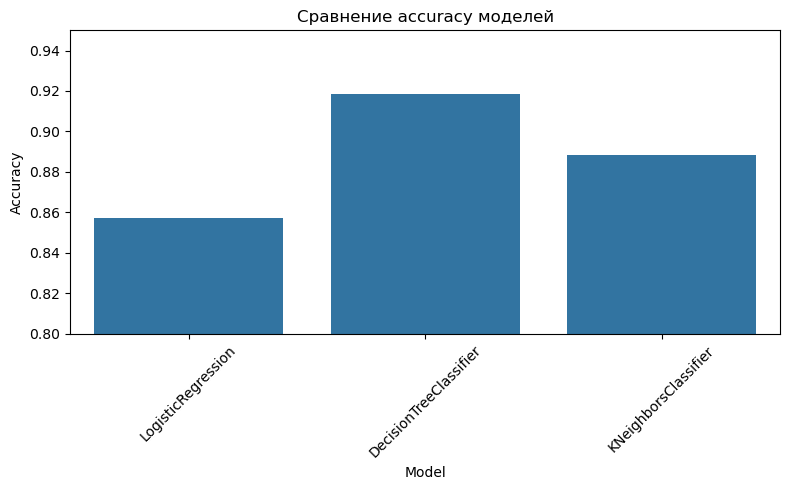

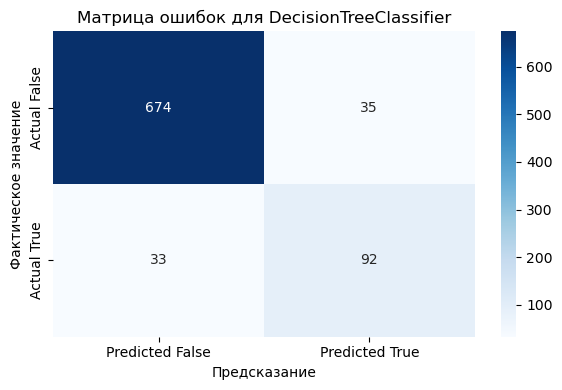

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


data = pd.read_csv('telecom_churn.csv')


print("Количество строк и столбцов:", data.shape)
print("\nТипы данных:\n", data.dtypes)
print("\nПропуски:", data.isnull().sum().sum())
print("\nРаспределение целевой переменной 'churn':\n", data['churn'].value_counts(normalize=True))


X = data.drop('churn', axis=1)
y = data['churn']

categorical_features = ['state', 'international plan', 'voice mail plan']
numerical_features = [col for col in X.columns if col not in categorical_features and col!='phone number']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "DecisionTreeClassifier": DecisionTreeClassifier(random_state=42),
    "KNeighborsClassifier": KNeighborsClassifier()
}

pipelines = {
    name: Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    for name, model in models.items()
}

results = {}
for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = {"accuracy": accuracy, "predictions": y_pred}


accuracy_table = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[name]['accuracy'] for name in results]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=accuracy_table, x='Model', y='Accuracy')
plt.title('Сравнение accuracy моделей')
plt.ylim(0.8, 0.95)
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

best_model_name = max(results, key=lambda x: results[x]['accuracy'])
best_model_predictions = results[best_model_name]['predictions']

cm = confusion_matrix(y_test, best_model_predictions)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted False', 'Predicted True'],
            yticklabels=['Actual False', 'Actual True'])
plt.title(f'Матрица ошибок для {best_model_name}')
plt.xlabel('Предсказание')
plt.ylabel('Фактическое значение')
plt.tight_layout()
plt.show()